In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [ ]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')
display(train.head())
print(train.shape,test.shape)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


(1460, 81) (1459, 80)


In [ ]:
X=train.drop('SalePrice',axis=1)
y=train['SalePrice']

In [ ]:
num=X.select_dtypes(include=['int64','float64']).columns
cat=X.select_dtypes(include='object').columns

In [ ]:
pre=ColumnTransformer([
 ('num',Pipeline([('imp',SimpleImputer(strategy='median'))]),num),
 ('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),
                  ('oh',OneHotEncoder(handle_unknown='ignore'))]),cat)
])

In [ ]:
models={
'Linear Regression':LinearRegression(),
'Decision Tree':DecisionTreeRegressor(random_state=42),
'Random Forest':RandomForestRegressor(n_estimators=200,random_state=42)
}

In [ ]:
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)
results=[]
best=None
best_r2=-1
for name,model in models.items():
    pipe=Pipeline([('pre',pre),('model',model)])
    pipe.fit(X_train,y_train)
    pred=pipe.predict(X_val)
    mae=mean_absolute_error(y_val,pred)
    mse=mean_squared_error(y_val,pred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_val,pred)
    results.append([name,mae,rmse,r2])
    print(name,mae,rmse,r2)
    if r2>best_r2:
        best_r2=r2
        best=pipe

Linear Regression 20485.659297118313 31327.795381404227 0.8720483670512569
Decision Tree 27582.674657534248 41784.63229019387 0.7723753268810465
Random Forest 17494.2626369863 28480.77943628507 0.8942476792527724


In [ ]:
res=pd.DataFrame(results,columns=['Model','MAE','RMSE','R2'])
display(res.sort_values('R2',ascending=False))

,Model,MAE,RMSE,R2
2,Random Forest,17494.262637,28480.779436,0.894248
0,Linear Regression,20485.659297,31327.795381,0.872048
1,Decision Tree,27582.674658,41784.632290,0.772375


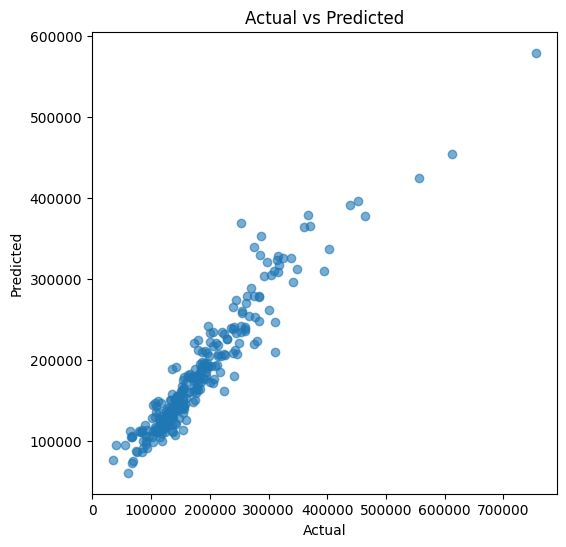

In [ ]:
pred=best.predict(X_val)
plt.figure(figsize=(6,6))
plt.scatter(y_val,pred,alpha=0.6)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [ ]:
best.fit(X,y)
test_pred=best.predict(test)
sub=pd.DataFrame({'Id':test['Id'],'SalePrice':test_pred})
sub.to_csv('submission.csv',index=False)
print('Saved submission.csv')

Saved submission.csv
